In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import joblib

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder
)

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score
)

# Classification Models

from sklearn.linear_model import LogisticRegression

from sklearn.tree import DecisionTreeClassifier

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

from sklearn.neighbors import KNeighborsClassifier

from sklearn.naive_bayes import GaussianNB

from sklearn.svm import SVC

from xgboost import XGBClassifier

from catboost import CatBoostClassifier

# Metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [2]:
df=pd.read_csv('../data/da-loanDefaulter.csv')

In [3]:
df.head()

,LoanID,Name-Surname,Gender,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,...,Low_Credit_Flag,Monthly_Income,Estimated_EMI,EMI_to_Income,Disposable_Income,Income_After_EMI,CreditScore_Bucket,Income_Group,Employment_Stability,Loan_Burden
0,I38PQUQS96,Advik Maharaj,Male,56,85994,50587,520,80,4,15.23,...,1,7166.166667,1759.318045,0.245503,48156.64,5406.848622,Poor,High,1.428571,0.258835
1,HPSK72WA7R,Isaac Dewan,Male,69,50432,124440,458,15,1,4.81,...,1,4202.666667,2337.519546,0.556199,16138.24,1865.147121,Poor,Medium,0.217391,1.677887
2,C1OZ6DPJ8Y,Chameli Sami,Female,46,84208,129188,451,26,3,21.17,...,1,7017.333333,6649.201648,0.947540,58103.52,368.131686,Poor,High,0.565217,0.475588
3,V2KKSFM3UN,Alexander Chander,Male,32,31713,44799,743,0,3,7.07,...,0,2642.750000,2007.188719,0.759508,24419.01,635.561281,Very Good,Low,0.000000,0.324907
4,EY08JDHTZP,Jackson Tiwari,Male,60,20437,9139,633,8,4,6.51,...,0,1703.083333,216.773108,0.127283,5517.99,1486.310225,Fair,Low,0.133333,0.326441


In [4]:
df.columns

Index(['LoanID', 'Name-Surname', 'Gender', 'Age', 'Income', 'LoanAmount',
       'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate',
       'LoanTerm', 'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner', 'Default',
       'Loan_to_Income', 'Credit_per_Line', 'Income_per_Employment',
       'Interest_Burden', 'High_DTI_Flag', 'Low_Credit_Flag', 'Monthly_Income',
       'Estimated_EMI', 'EMI_to_Income', 'Disposable_Income',
       'Income_After_EMI', 'CreditScore_Bucket', 'Income_Group',
       'Employment_Stability', 'Loan_Burden'],
      dtype='object')

In [5]:
df.drop(columns=['LoanID', 'Name-Surname', 'Gender'], inplace=True)

In [6]:
# ==========================================
# TRAIN TEST SPLIT
# ==========================================

X = df.drop("Default", axis=1)

y = df["Default"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(204277, 31)
(51070, 31)


In [7]:
identifier_features = [
    "LoanID",
    "Name-Surname"
]

binary_features = [
    "HasMortgage",
    "HasDependents",
    "HasCoSigner"
]

flag_features = [
    "High_DTI_Flag",
    "Low_Credit_Flag"
]

ordinal_features = [
    "Education",
    "CreditScore_Bucket",
    "Income_Group"
]

nominal_features = [
    "EmploymentType",
    "MaritalStatus",
    "LoanPurpose"
]

numerical_features = [
    "Age",
    "Income",
    "LoanAmount",
    "CreditScore",
    "MonthsEmployed",
    "NumCreditLines",
    "InterestRate",
    "LoanTerm",
    "DTIRatio",
    "Loan_to_Income",
    "Credit_per_Line",
    "Income_per_Employment",
    "Interest_Burden",
    "Monthly_Income",
    "Estimated_EMI",
    "EMI_to_Income",
    "Disposable_Income",
    "Income_After_EMI",
    "Employment_Stability",
    "Loan_Burden",
    "High_DTI_Flag",
    "Low_Credit_Flag"
]

In [8]:
binary_transformer = OrdinalEncoder()

ordinal_transformer = OrdinalEncoder(
    categories=[
        [
            "High School",
            "Bachelor's",
            "Master's",
            "PhD"
        ],
        [
            "Poor",
            "Fair",
            "Good",
            "Very Good",
            "Excellent"
        ],
        [
            "Low",
            "Medium",
            "High",
            "Very High"
        ]
    ]
)


In [9]:

nominal_transformer = OneHotEncoder(
    drop="first",
    handle_unknown="ignore"
)

numeric_transformer = StandardScaler()

preprocessor = ColumnTransformer(

    transformers=[

        (
            "binary",
            OrdinalEncoder(
                categories=[
                    ["No","Yes"],
                    ["No","Yes"],
                    ["No","Yes"]
                ]
            ),
            binary_features
        ),

        (
            "ordinal",
            ordinal_transformer,
            ordinal_features
        ),

        (
            "nominal",
            nominal_transformer,
            nominal_features
        ),

        (
            "numeric",
            numeric_transformer,
            numerical_features
        )

    ]
)

In [10]:

models = {

    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight="balanced"
    ),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ),

    "Extra Trees": ExtraTreesClassifier(
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    ),

    "AdaBoost": AdaBoostClassifier(
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ),

    "CatBoost": CatBoostClassifier(
        random_state=42,
        verbose=False
    ),

    "KNN": KNeighborsClassifier(),

    "Gaussian NB": GaussianNB()

}

In [11]:
# ==========================================
# MODEL EVALUATION
# ==========================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

def evaluate_model(model, X_train, X_test, y_train, y_test):

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    y_prob = pipeline.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(y_test, y_pred)

    recall = recall_score(y_test, y_pred)

    f1 = f1_score(y_test, y_pred)

    roc_auc = roc_auc_score(y_test, y_prob)

    return (
        pipeline,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    )

In [12]:
# ==========================================
# TRAIN ALL MODELS
# ==========================================

results = []

trained_models = {}

for name, model in models.items():

    print(f"Training {name}...")

    pipeline, accuracy, precision, recall, f1, roc_auc = evaluate_model(

        model,
        X_train,
        X_test,
        y_train,
        y_test

    )

    trained_models[name] = pipeline

    results.append({

        "Model": name,

        "Accuracy": accuracy,

        "Precision": precision,

        "Recall": recall,

        "F1 Score": f1,

        "ROC AUC": roc_auc

    })

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training Extra Trees...
Training AdaBoost...
Training Gradient Boosting...
Training XGBoost...
Training CatBoost...
Training KNN...
Training Gaussian NB...


In [13]:
# ==========================================
# MODEL COMPARISON
# ==========================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(

    by="ROC AUC",

    ascending=False

).reset_index(drop=True)

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.690229,0.227591,0.696510,0.343078,0.761489
1,Gradient Boosting,0.886450,0.611864,0.060867,0.110719,0.758922
2,CatBoost,0.885863,0.565722,0.074018,0.130908,0.754560
3,AdaBoost,0.886195,0.605310,0.057663,0.105296,0.750357
4,XGBoost,0.885158,0.535256,0.084471,0.145915,0.744280
5,Random Forest,0.885491,0.637874,0.032372,0.061617,0.732416
6,Extra Trees,0.885275,0.660714,0.024954,0.048091,0.731253
7,Gaussian NB,0.825827,0.263259,0.277862,0.270363,0.696370
8,KNN,0.874721,0.338632,0.082617,0.132827,0.620406
9,Decision Tree,0.802604,0.198751,0.230821,0.213589,0.554277


In [14]:
# ==========================================
# BEST MODEL
# ==========================================

best_model_name = results_df.iloc[0]["Model"]

print("Best Model :", best_model_name)

best_pipeline = trained_models[best_model_name]

Best Model : Logistic Regression


In [16]:
models = {

    "Logistic Regression":
    LogisticRegression(
        random_state=42,
        max_iter=1000
    ),

    "Random Forest":
    RandomForestClassifier(
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting":
    GradientBoostingClassifier(
        random_state=42
    ),

    "XGBoost":
    XGBClassifier(
        random_state=42,
        eval_metric="logloss",
        n_jobs=-1
    ),

    "CatBoost":
    CatBoostClassifier(
        verbose=False,
        random_state=42
    )

}

In [17]:
# ==========================================
# HYPERPARAMETER GRIDS
# ==========================================

param_grids = {

    "Logistic Regression": {

        "classifier__C": [0.01, 0.1, 1, 10, 100],

        "classifier__penalty": ["l2"],

        "classifier__solver": ["lbfgs"]

    },

    "Random Forest": {

        "classifier__n_estimators": [100, 200, 300],

        "classifier__max_depth": [None, 10, 20, 30],

        "classifier__min_samples_split": [2, 5, 10],

        "classifier__min_samples_leaf": [1, 2, 4]

    },

    "XGBoost": {

        "classifier__n_estimators": [100, 200, 300],

        "classifier__max_depth": [3, 5, 7],

        "classifier__learning_rate": [0.01, 0.05, 0.1],

        "classifier__subsample": [0.8, 1.0],

        "classifier__colsample_bytree": [0.8, 1.0]

    },

    "CatBoost": {

        "classifier__iterations": [200, 300, 500],

        "classifier__depth": [4, 6, 8],

        "classifier__learning_rate": [0.01, 0.05, 0.1]

    }

}

In [18]:
models_to_tune = {

    "Logistic Regression":

    LogisticRegression(

        random_state=42,

        max_iter=1000,

        class_weight="balanced"

    ),

    "Random Forest":

    RandomForestClassifier(

        random_state=42,

        class_weight="balanced",

        n_jobs=-1

    ),

    "XGBoost":

    XGBClassifier(

        random_state=42,

        eval_metric="logloss",

        scale_pos_weight=7.61,

        n_jobs=-1

    ),

    "CatBoost":

    CatBoostClassifier(

        random_state=42,

        auto_class_weights="Balanced",

        verbose=False

    )

}

In [19]:
from sklearn.model_selection import RandomizedSearchCV

best_models = {}

results = []

for name in models_to_tune:

    print("="*80)

    print(f"Tuning {name}")

    print("="*80)

    pipeline = Pipeline([

        ("preprocessor", preprocessor),

        ("classifier", models_to_tune[name])

    ])

    random_search = RandomizedSearchCV(

        estimator=pipeline,

        param_distributions=param_grids[name],

        n_iter=5,

        cv=3,

        scoring="roc_auc",

        verbose=2,

        random_state=42,

        n_jobs=-1

    )

    random_search.fit(

        X_train,

        y_train

    )

    best_models[name] = random_search.best_estimator_

    print("\nBest Parameters")

    print(random_search.best_params_)

    print("\nBest ROC-AUC")

    print(random_search.best_score_)

Tuning Logistic Regression
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Best Parameters
{'classifier__solver': 'lbfgs', 'classifier__penalty': 'l2', 'classifier__C': 0.01}

Best ROC-AUC
0.7557078479963565
Tuning Random Forest
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Best Parameters
{'classifier__n_estimators': 300, 'classifier__min_samples_split': 5, 'classifier__min_samples_leaf': 4, 'classifier__max_depth': 20}

Best ROC-AUC
0.7390491372803254
Tuning XGBoost
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Best Parameters
{'classifier__subsample': 1.0, 'classifier__n_estimators': 300, 'classifier__max_depth': 3, 'classifier__learning_rate': 0.05, 'classifier__colsample_bytree': 1.0}

Best ROC-AUC
0.7528690136129349
Tuning CatBoost
Fitting 3 folds for each of 5 candidates, totalling 15 fits

Best Parameters
{'classifier__learning_rate': 0.05, 'classifier__iterations': 300, 'classifier__depth': 6}

Best ROC-AUC
0.7536393832517629


In [20]:
from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    roc_auc_score

)

final_results = []

for name, model in best_models.items():

    y_pred = model.predict(X_test)

    y_prob = model.predict_proba(X_test)[:,1]

    final_results.append({

        "Model": name,

        "Accuracy": accuracy_score(y_test,y_pred),

        "Precision": precision_score(y_test,y_pred),

        "Recall": recall_score(y_test,y_pred),

        "F1 Score": f1_score(y_test,y_pred),

        "ROC AUC": roc_auc_score(y_test,y_prob)

    })

results_df = pd.DataFrame(final_results)

results_df.sort_values(

    by="ROC AUC",

    ascending=False

)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.690679,0.227849,0.696341,0.343351,0.761495
2,XGBoost,0.692696,0.227549,0.687405,0.341915,0.760386
3,CatBoost,0.694047,0.229218,0.691789,0.344341,0.760317
1,Random Forest,0.872978,0.410553,0.215141,0.282332,0.747087


In [21]:
best_model_name = results_df.sort_values(

    by="ROC AUC",

    ascending=False

).iloc[0]["Model"]

print(best_model_name)

best_model = best_models[best_model_name]

Logistic Regression


In [22]:
from sklearn.metrics import classification_report

y_pred = best_model.predict(X_test)

print(classification_report(

    y_test,

    y_pred

))

              precision    recall  f1-score   support

           0       0.95      0.69      0.80     45139
           1       0.23      0.70      0.34      5931

    accuracy                           0.69     51070
   macro avg       0.59      0.69      0.57     51070
weighted avg       0.86      0.69      0.74     51070



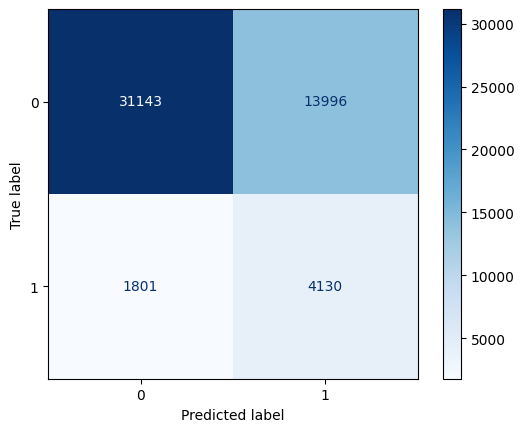

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(

    best_model,

    X_test,

    y_test,

    cmap="Blues"

)

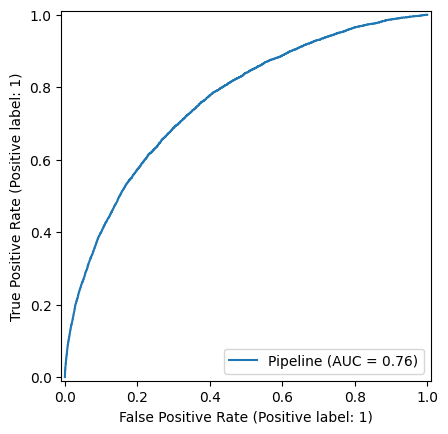

In [24]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(

    best_model,

    X_test,

    y_test

)